In [8]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

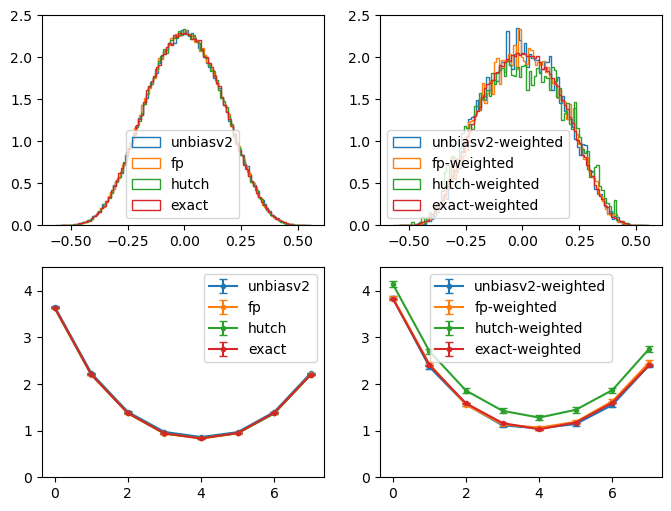

In [20]:
integrators = ['unbiasv2', 'fp', 'hutch', 'exact']
integratore = ['unbiasv2']
dts = [0.0125, 0.05, 0.05, 0.05]

fig, ax = plt.subplots(2, 2, figsize=(8, 6))
ax = ax.flatten()
for int in integratore:
    for dt, integrator in zip(dts, integrators):
        susc = np.load(f"../results/npy/L8_inteval{int}_integrator{integrator}_dt{dt}_bs200000_noise_1/susc.npy")
        logw = np.load(f"../results/npy/L8_inteval{int}_integrator{integrator}_dt{dt}_bs200000_noise_1/logw.npy")
        twop = np.load(f"../results/npy/L8_inteval{int}_integrator{integrator}_dt{dt}_bs200000_noise_1/twop.npy")
        ax[0].hist(susc, bins=100, histtype='step', density=True, label=integrator)
        ax[1].hist(susc, bins=100, weights=np.exp(logw-sp.special.logsumexp(logw)), histtype='step', density=True, label=f"{integrator}-weighted")
        avg = []
        err = []
        cor = np.arange(0, twop.shape[1], 1)
        for i in range(twop.shape[1]):
            inds = np.random.randint(0, len(twop), (100, len(twop)))
            boots = twop[:, i][inds].mean(-1)
            avg.append(np.mean(boots))
            err.append(np.std(boots))
        ax[2].errorbar(cor, avg, err, label = integrator, marker='.', capsize=3)
        avg = []
        err = []
        cor = np.arange(0, twop.shape[1], 1)
        for i in range(twop.shape[1]):
            inds = np.random.randint(0, len(twop), (100, len(twop)))
            boots = twop[:, i][inds]
            logws = logw[inds]
            ws = np.exp(logws - sp.special.logsumexp(logws, axis=-1, keepdims=True))
            boots = np.sum(boots * ws, -1)
            avg.append(np.mean(boots))
            err.append(np.std(boots))
        ax[3].errorbar(cor, avg, err, label=f"{integrator}-weighted", marker='.', capsize=3)
for axis in ax:
    axis.legend()
ax[0].set_ylim(0, 2.5)
ax[1].set_ylim(0, 2.5)
ax[2].set_ylim(0, 4.5)
ax[3].set_ylim(0, 4.5)
plt.show()
